# PCD Assignment 02: Image Enhancement

**Course:** Pengolahan Citra Digital

**Task:**

**Name:** Renata Ayu Sekar Kumala (25/557585/PA/23428)

## Objective
This notebook implements image enhancement for four image conditions: blurred, dark, bright, and low-contrast images. Each degraded image is processed with a suitable enhancement method, then compared visually and quantitatively with the original image.

The experiment uses one generated RGB image as a reference. This makes the results reproducible and allows us to calculate the Peak Signal-to-Noise Ratio (PSNR) before and after enhancement.

## Workflow
1. Import the required libraries and prepare output folders.
2. Create the reference image.
3. Generate four degraded versions.
4. Apply an enhancement method to each version.
5. Compare the images and calculate PSNR.

## 1. Libraries and Output Folders

NumPy is used for pixel calculations, Pillow for image creation and processing, and Matplotlib for visualization. The images folder stores the reference and degraded images, while the results folder stores the enhanced images and evaluation results.

In [1]:
from pathlib import Path
import csv
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

IMAGES = Path("images")
RESULTS = Path("results")
IMAGES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

## 2. Create the Reference Image

The reference is a generated landscape image containing color gradients, solid-colored objects, and fine edges. These features make changes in brightness, contrast, and sharpness easier to observe.

Two small black and white patches are also included. They provide known minimum and maximum pixel values for the controlled contrast-stretching experiment. Since this image is generated by code, the experiment does not depend on an external image file.

/tmp/ipykernel_3013/158791696.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(sky, "RGB")


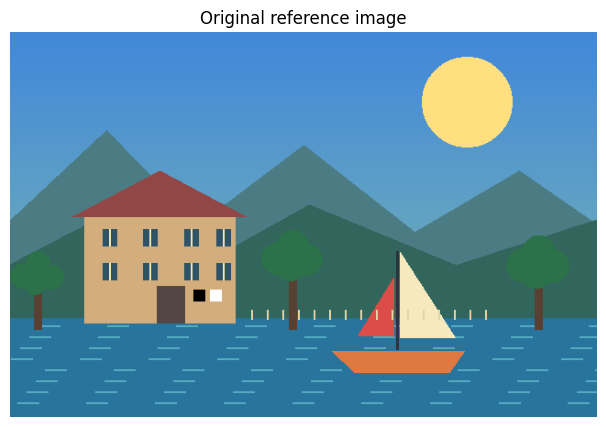

In [2]:
def make_original():
    """Draw an original scene with gradients, flat colors, thin details and edges."""
    w, h = 640, 420
    yy, xx = np.mgrid[0:h, 0:w]
    sky = np.zeros((h, w, 3), dtype=np.uint8)
    sky[..., 0] = np.clip(65 + yy * .16, 0, 255)
    sky[..., 1] = np.clip(136 + yy * .13, 0, 255)
    sky[..., 2] = np.clip(218 - yy * .11, 0, 255)
    im = Image.fromarray(sky, "RGB")
    d = ImageDraw.Draw(im)
    d.ellipse((449, 27, 547, 125), fill=(255, 223, 127))
    d.polygon([(0, 205), (105, 107), (205, 210), (320, 123),
               (441, 218), (555, 151), (640, 210), (640, 315), (0, 315)],
              fill=(76, 124, 131))
    d.polygon([(0, 253), (90, 206), (188, 265), (326, 188),
               (486, 254), (640, 204), (640, 355), (0, 355)], fill=(50, 101, 92))
    d.rectangle((0, 312, 639, 419), fill=(41, 116, 156))
    for y in range(320, 415, 12):
        for x in range((y * 7) % 47, 640, 75):
            d.line((x, y, x + 23, y), fill=(85, 171, 194), width=2)
    d.rectangle((81, 195, 245, 317), fill=(211, 174, 124))
    d.polygon([(68, 201), (163, 151), (257, 201)], fill=(147, 70, 70))
    for x in (101, 145, 190, 225):
        for y in (215, 252):
            d.rectangle((x, y, x + 15, y + 18), fill=(46, 82, 102))
            d.line((x + 7, y, x + 7, y + 18), fill=(244, 230, 184), width=2)
    d.rectangle((160, 277, 190, 317), fill=(82, 71, 68))
    d.polygon([(351, 348), (495, 348), (479, 371), (375, 371)], fill=(222, 122, 65))
    d.line((422, 239, 422, 346), fill=(43, 51, 63), width=3)
    d.polygon([(425, 240), (425, 333), (485, 333)], fill=(247, 233, 190))
    d.polygon([(418, 268), (418, 332), (379, 331)], fill=(220, 76, 72))
    for x, y, r in [(30, 277, 26), (308, 258, 35), (576, 265, 37)]:
        d.rectangle((x - 4, y, x + 4, 324), fill=(88, 65, 50))
        for dx, dy in [(-17, -11), (15, -10), (0, -25), (-3, -4)]:
            d.ellipse((x + dx - r // 2, y + dy - r // 2,
                       x + dx + r // 2, y + dy + r // 2), fill=(43, 113, 73))
    for i in range(16):
        x = 263 + i * 17
        d.line((x, 303, x, 313), fill=(228, 212, 168), width=2)
    # Two small grayscale calibration patches make the complete 0-255 range
    # observable in each channel for the controlled contrast experiments.
    d.rectangle((200, 281, 212, 293), fill=(0, 0, 0))
    d.rectangle((218, 281, 230, 293), fill=(255, 255, 255))
    return im

original = make_original()
original.save(IMAGES / "original.png")
plt.figure(figsize=(9, 5))
plt.imshow(original)
plt.title("Original reference image")
plt.axis("off")
plt.show()

## 3. Generate Degraded Images

Four problems are simulated from the same reference image:

| Image | Simulated problem |
| --- | --- |
| Blurred | A Gaussian blur softens edges and fine details. |
| Dark | Pixel intensities are reduced to simulate underexposure. |
| Bright | Pixel intensities are increased to simulate overexposure. |
| Low contrast | The intensity range is compressed, making colors look muted. |

Using the same reference for every case allows a direct comparison between the degraded and enhanced images.

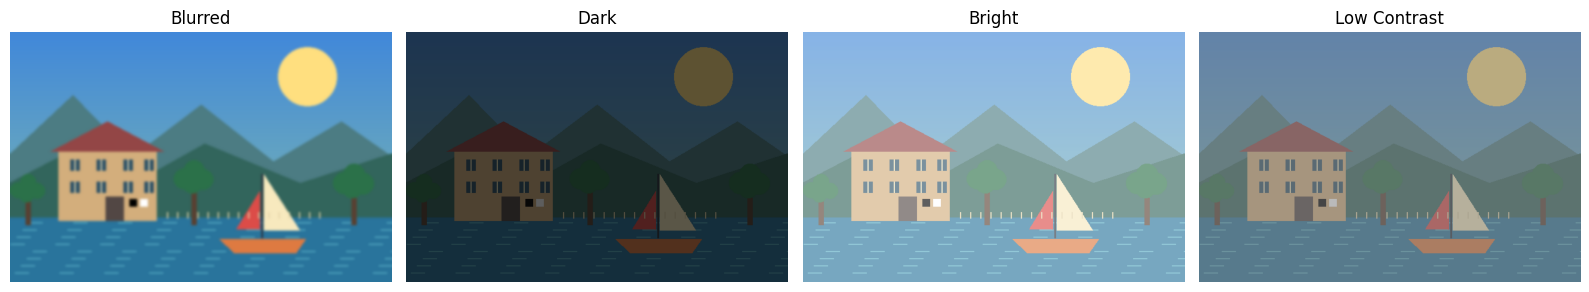

In [3]:
def degrade(original):
    a = np.asarray(original).astype(np.float32)
    return {
        "blurred": original.filter(ImageFilter.GaussianBlur(radius=2.0)),
        "dark": Image.fromarray(np.uint8(np.clip(a * .34 + 7, 0, 255))),
        "bright": Image.fromarray(np.uint8(np.clip(a * .63 + 94, 0, 255))),
        "low_contrast": Image.fromarray(np.uint8(np.clip(a * .46 + 69, 0, 255))),
    }

degraded = degrade(original)
for name, image in degraded.items():
    image.save(IMAGES / f"{name}.png")
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, image) in zip(axes, degraded.items()):
    ax.imshow(image)
    ax.set_title(name.replace("_", " ").title())
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Apply Image Enhancement

A different method is selected for each image condition:

| Image | Enhancement method | Purpose |
| --- | --- | --- |
| Blurred | Unsharp masking | Strengthens edges to make details appear clearer. |
| Dark | Contrast stretching and gamma correction | Expands the intensity range and adjusts darker tones. |
| Bright | Contrast stretching | Redistributes available pixel values across a wider range. |
| Low contrast | Contrast stretching | Increases the separation between dark and bright regions. |

Contrast stretching works particularly well in this controlled experiment because the black and white reference patches define the full intensity range. However, enhancement cannot recreate information that has been completely lost through blur or clipping.

In [4]:
def stretch(image, low=0, high=100):
    """Stretch each RGB channel from its percentile limits to [0, 255]."""
    a = np.asarray(image).astype(np.float32)
    lo = np.percentile(a, low, axis=(0, 1), keepdims=True)
    hi = np.percentile(a, high, axis=(0, 1), keepdims=True)
    out = (a - lo) * 255.0 / np.maximum(hi - lo, 1)
    return Image.fromarray(np.clip(out, 0, 255).astype(np.uint8), "RGB")

def gamma_correct(image, gamma=0.9):
    """For gamma < 1, brighten normalized intensity without changing dimensions."""
    a = np.asarray(image).astype(np.float32) / 255
    return Image.fromarray(np.uint8(np.clip(255 * a ** gamma, 0, 255)), "RGB")

def enhance(degraded):
    return {
        "blurred": degraded["blurred"].filter(
            ImageFilter.UnsharpMask(radius=2.0, percent=190, threshold=1)),
        "dark": gamma_correct(stretch(degraded["dark"], 0, 100), gamma=0.98),
        "bright": stretch(degraded["bright"], 0, 100),
        "low_contrast": stretch(degraded["low_contrast"], 0, 100),
    }

enhanced = enhance(degraded)
for name, image in enhanced.items():
    image.save(RESULTS / f"{name}_enhanced.png")

/tmp/ipykernel_3013/3057669860.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.clip(out, 0, 255).astype(np.uint8), "RGB")
/tmp/ipykernel_3013/3057669860.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.uint8(np.clip(255 * a ** gamma, 0, 255)), "RGB")


## 5. Visual Comparison

The following figure displays three images for each condition: the original reference, the degraded input, and the enhanced output.

The visual comparison helps identify changes that a numerical score alone may not describe, such as clearer edges, restored colors, or possible sharpening artifacts.

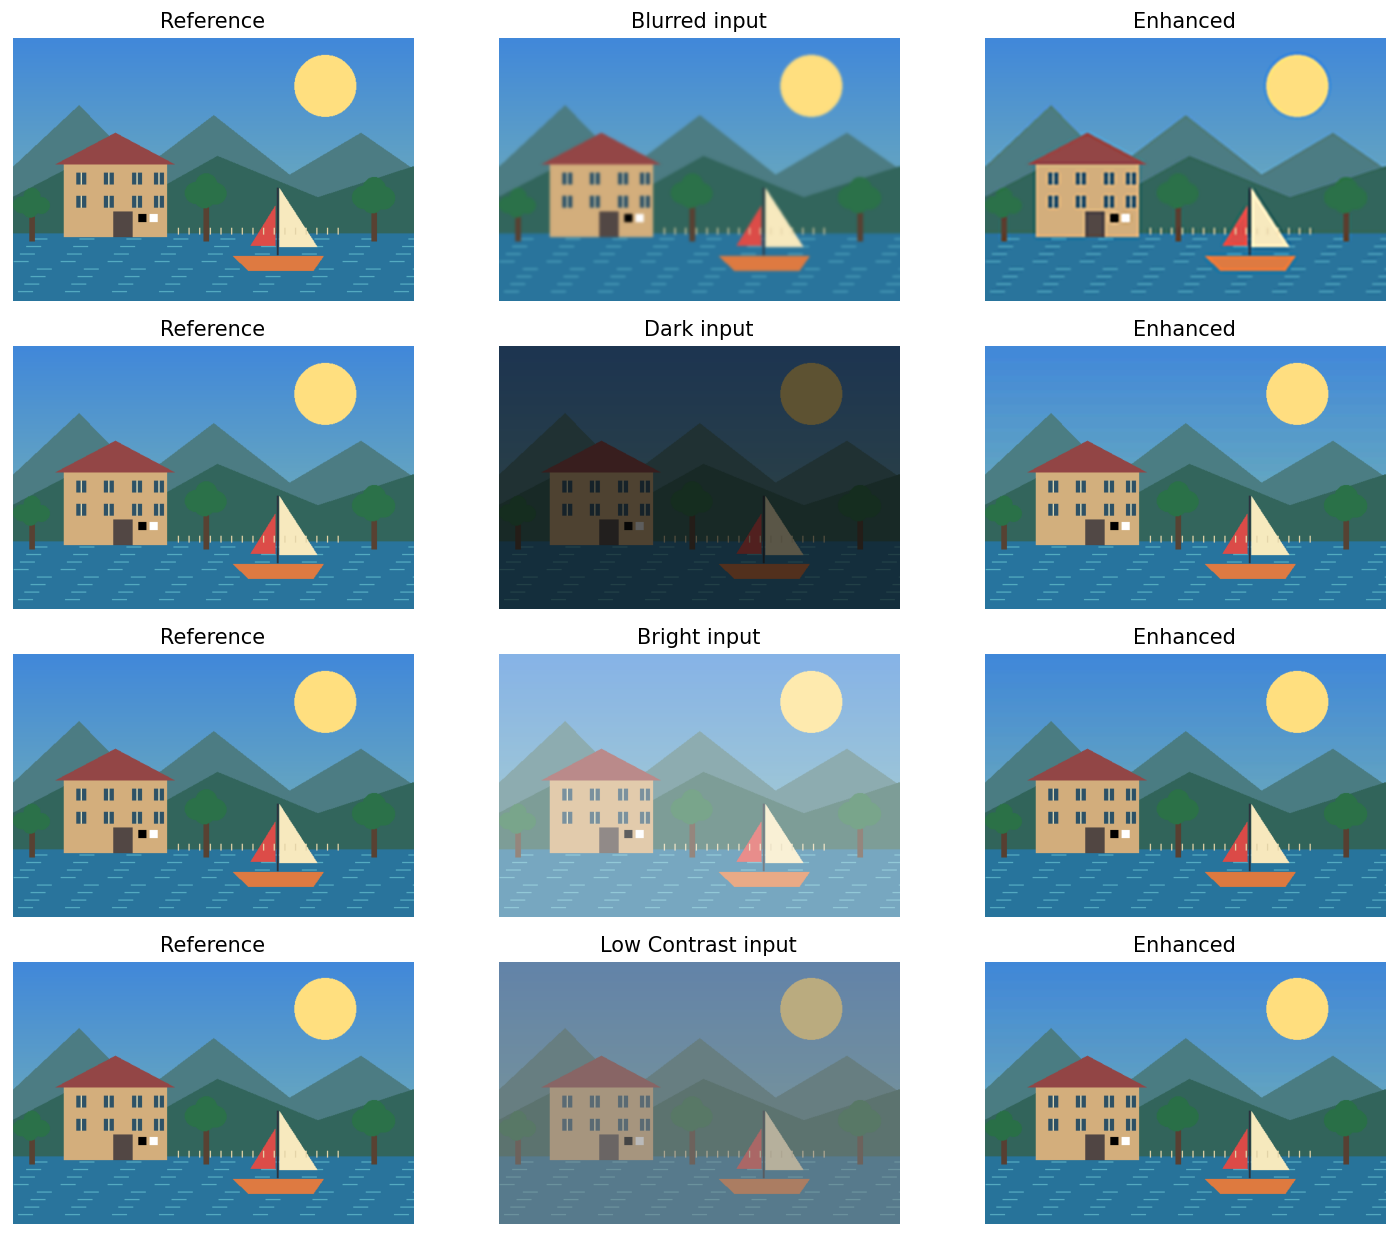

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(12, 10), dpi=125)
for row, name in enumerate(degraded):
    for col, (title, image) in enumerate([
        ("Reference", original),
        (name.replace("_", " ").title() + " input", degraded[name]),
        ("Enhanced", enhanced[name]),
    ]):
        axes[row, col].imshow(image)
        axes[row, col].set_title(title)
        axes[row, col].axis("off")
plt.tight_layout()
fig.savefig(RESULTS / "comparison.png", bbox_inches="tight")
plt.show()

### 6. Quantitative Evaluation: PSNR

To measure the enhancement result, we compare each image with the original using **Peak Signal-to-Noise Ratio (PSNR)**. First, we calculate the Mean Squared Error (MSE):

$$
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(I_i-K_i)^2
$$

Then, we calculate PSNR:

$$
\mathrm{PSNR}=10\log_{10}\left(\frac{255^2}{\mathrm{MSE}}\right)
$$

Here, $I$ is the original image, $K$ is the image being evaluated, and $N$ is the total number of RGB pixel values. **Higher PSNR** means the image is numerically closer to the original.

In [6]:
def psnr(reference, test):
    a = np.asarray(reference, dtype=np.float64)
    b = np.asarray(test, dtype=np.float64)
    mse = np.mean((a - b) ** 2)
    return float("inf") if mse == 0 else 10 * math.log10(255 ** 2 / mse)

records = []
for name in degraded:
    before = psnr(original, degraded[name])
    after = psnr(original, enhanced[name])
    records.append({
        "case": name,
        "psnr_before_db": round(before, 2),
        "psnr_after_db": round(after, 2),
        "gain_db": round(after - before, 2),
    })

with (RESULTS / "metrics.csv").open("w", newline="") as out:
    writer = csv.DictWriter(out, fieldnames=records[0].keys())
    writer.writeheader()
    writer.writerows(records)

print(f"{'Case':<15} {'Before (dB)':>12} {'After (dB)':>12} {'Gain (dB)':>11}")
for r in records:
    print(f"{r['case']:<15} {r['psnr_before_db']:>12.2f} "
          f"{r['psnr_after_db']:>12.2f} {r['gain_db']:>+11.2f}")

Case             Before (dB)   After (dB)   Gain (dB)
blurred                28.09        29.55       +1.46
dark                    9.66        47.41      +37.75
bright                 13.88        47.47      +33.60
low_contrast           18.67        45.45      +26.78


## 7. Results and Discussion

| Condition | Before (dB) | After (dB) | Improvement (dB) |
| --- | ---: | ---: | ---: |
| Blurred | 28.09 | 29.55 | +1.46 |
| Dark | 9.66 | 47.41 | +37.75 |
| Bright | 13.88 | 47.47 | +33.60 |
| Low contrast | 18.67 | 45.45 | +26.78 |

All four enhanced images have higher PSNR than their degraded versions. Unsharp masking improves the blurred image, although its improvement is smaller because blur removes spatial detail that cannot be perfectly reconstructed.

The dark, bright, and low-contrast images show much larger improvements. Their degradations were created using controlled intensity transformations, so contrast stretching can approximately reverse them. These high scores should not be interpreted as expected results for all real photographs. Camera noise, uneven lighting, clipped shadows, and saturated highlights would make restoration more difficult.

## Conclusion

The experiment demonstrates that image enhancement should be chosen according to the image problem. Unsharp masking improves apparent sharpness, while contrast stretching and gamma correction improve images with unsuitable intensity ranges. Both visual inspection and PSNR are needed to interpret the results, especially when comparing controlled images with real-world photographs.